In [1]:
%load_ext autoreload
%autoreload 2

# Project: Image segmentation

## Goal

The goal in this project is to create a tissue segmentation method, based on the techniques you have seen so far. This method should generalize well to different images. We will be using the same images as in the segmentation exercises.

Similar to project 1, your assignment is to investigate of what method or combination of methods is most suitable for doing this. In this investigation, you should explain the choices you are making, for example by referring to what you studied in class, showing plots etc.

There isn't one correct answer for the project. Your reasoning should show the reader that you understand the methods you studied, how to apply them to tissue segmentation and interpret the results. Consider these two example answers:

- (Poor) "We tried all combinations of features, and features A and B gave the best error, therefore you should always use features A and B"
- (Good) "Based on the scatterplots, we saw that features A and B, and features B and C, provided a good separation of the classes. We created learning curves for these two combinations. For features A and B, the error was lower for all training sizes. We then used the classifier trained on 1000 samples to visualize the predicted mask next to the true mask. Here we can see that the classifier makes many errors for the skull pixels, because their appearance is similar to pixels inside the brain."

The assignment consists of two parts, as a first step there is preliminary guided project work, and as a second step you must investigate a suitable research question based on the methods you have developed. A research question based on the preliminary guided project work below, completing the programming tasks and answering the theory questions, is the minimal solution to this project. If this is done well and accompanied by a suitable report, this will be graded with a ‘sufficient’ grade. To achieve higher grades, you need to go beyond the minimal solution. You should use what you have implemented and the available data to come up with and answer a suitable research question. Write about this in your report.


## Deliverables
A completed version of this notebook, the documented python code that you developed, and a report describing your research question, results and analysis. The report is expected in a short, concise format. It focusses on your specific research questions, results and discussion. The lecturers already know the background, the data and the general methodology. Your report therefore does not need to include an introduction on the clinical problem nor explanations of the background of image registration. You do have to include your design choices and motivation thereof.

Aim to present your most important findings in the main body of the report and (if needed) any additional information in an appendix. The following report structure is suggested for the main body of the report:

1. Introduce research question and hypothesis with its motivation (0.5 page)
2. Study design: which data did you use, what are the requirements of your method,
why did you make certain choices. Be as complete as possible w.r.t. the components
of a study design. (0.5 page)
3. Method, experiments and results for each research question (2 pages)
4. Discussion section with analysis of the results. (1 page)
5. Contributions: a brief description by each group member of their activities in the project which can be used to to adjust individual grades to reflect a student’s (lack of) contribution to the group
6. If you use large language models (such as ChatGPT) in your course work, you are required to declare how and for what they were used and to include a reflection on the use of such tools.

The page lengths above are indications. You are free to adapt them, with the constraint of a maximum length of five pages for the first four items listed.

The report must be submitted as a single PDF file. The documented code must be submitted as a single archive file (e.g. zip or 7z) that is self-contained and can be used to reproduce the results in the report. 

Note that there is no single correct solution for the project. You have to demonstrate to the reader that you understand the methods that you have studied and can critically analyze the results of applying the methods. Below, you can find a set of assignments (guided project work) that will help you get started with the project work and, when correctly completed, will present you with a **minimal solution**. Solutions which go beyond these assignments are of course encouraged. Additionally, include the solutions to the preliminary guided project work within this notebook in the archive file. 

## Assessment
The rubric that will be used for assessment of the project work is given in [this table](https://github.com/tueimage/8BE030-MIA/blob/master/rubric.md). Please

In [23]:
# IMPORTS
%matplotlib inline
import sys
sys.path.append("../code")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import segmentation_util as util
import segmentation as seg
import segmentation_project as project



np.random.seed(0)

## Preliminary guided project work
### 1. Creating datasets
1. Create a dataset for all the images, but where the labels are based on a different task: white matter vs gray matter vs cerebrospinal fluid.
2. Implement the missing functionality in `extract_features`. The final result should extract 5-10 features that you tried in the exercises, or created yourself, for a particular subject and slice.
3. Examine the (already implemented, but you might need to modify the location of the images it loads) function `create_dataset` which extracts the features for a several subjects and/or slices, and creates the labels (either for the brain/not brain task, or the tissue classification task). Create one training dataset for the tissue classification task.
4. Use `scatter_data` to look at the features you have. You can also look at PCA or subsets of the features. What can you say about the features?
5. In principle any type of processing you can apply to the image can be used to create more features. For example, if you enhance edges in the image, you can create a feature that provides information about whether that pixel is part of an edge or not. Think about the image processing techniques you learnt about in **8BB050** (for example, boundary extraction) and invent a new feature to add to your dataset. Implement it in a new function, for example `extract_myfeature` that has the image as input, and the feature vector as output.
    
    You should aim for your feature to be different (not perfectly correlated) from the ones you already have. Note that you cannot use the ground-truth image to create features - you want to be able to extract the feature, even if ground truth is not available.
    
    Your answer should include a description of the feature, the code to extract it, and a demonstration that shows it is different from the features you already have.

In [3]:
# 1.1 CREATE DATASET FOR THE IMAGES, WITH TISSUE LABELS BASED ON:
#     0 = background
#     1 = white matter
#     2 = grey matter 
#     3 = CSF

image_number = 1
slice_number = 1
task = "tissue"

X, y, feature_labels = util.create_dataset(image_number, slice_number, task) 

y = y.ravel()

print("Classes in y ((0=BG, 1=WM, 2=GM, 3=CSF):", np.unique(y))

Classes in y ((0=BG, 1=WM, 2=GM, 3=CSF): [0 1 2 3]


### 1.2 Implement missing functionality in extract_features()

For the segmentation, we used seven features for each pixel. These features were chosen because they give different types of information about the image. The first two features are the original T1 intensity T2 intensity values. These are important because different tissues appear differently in T1 and T2 MRI scans, making some tissues easier to seperate in the T1 image and others in the T2 image. So using both modalities gives the classifier more information than using only one image.

The third and fourth are the Gaussian-smoothed T1 and T2 images, using σ=20 pixels. These features give a more global view of the image by reducing small intensity variations and noise. The value σ=20 was chosen because it gives a clearly smoothed image while still keeping the main brain structure. This is also in line with the idea of Gaussian scale-space, where larger σ values represent the image at a coarser scale and fine details are gradually suppressed (Lindeberg, 1994).

The fifth and sixth features are the local variance of T1 and T2, calculated with a 5 x 5 pixel window. Local variance gives texture information by measuring how much the intensities change around a pixel. Homogeneous tissue regions usually have low variance, while tissue boundaries or noisy regions have higher variance. A 5 x 5 window was chosen because it is large enough to capture local texture, but still small enough to avoid mixing too many different tissue types near boundaries which would make the feature less precise for segmentation. This follows the idea that window-size selection in texture feature extraction involves a trade-off between texture description and accurate segmentation boundaries (Puig & García, 2001)

The final feature is T1-T2 intensity difference. This feature combines information from both modalities and can help differentiate between tissues that may look similar in one image but differ when comparing T1 and T2 intensities. Together theses seven features combine complementary information.

sources:
- Lindeberg, T. (1994). Scale-space theory: A basic tool for analysing structures at different scales. Journal of Applied Statistics, 21(2), 225–270. https://people.kth.se/~tony/papers/scsptheory-review.jas94.pdf
- Puig, D., & García, M. A. (2001). Determining optimal window size for texture feature extraction methods. In IX Spanish Symposium on Pattern Recognition and Image Analysis (Vol. 2, pp. 237–242).
https://www.researchgate.net/publication/228970104_Determining_optimal_window_size_for_texture_feature_extraction_methods

In [4]:
# 1.3 EXAMINE create_dataset(); CREATE TRAINING DATASET FOR TISSUE CLASSIFICATION TASK 

train_subject = 1
slice_number = 1
task = 'tissue'

X_train, y_train, feature_labels = util.create_dataset(train_subject, slice_number, task, include_edge=False)

y_train = y_train.ravel()

print('Training data shape:', X_train.shape)
print('Number of pixels:', X_train.shape[0])
print('Number of features:', X_train.shape[1])
print('Features extracted:')
for i, f in enumerate(feature_labels):
    print(f'{i}:{f}')

Training data shape: (57600, 7)
Number of pixels: 57600
Number of features: 7
Features extracted:
0:T1 intensity
1:T2 intensity
2:T1 Gaussian, σ=20
3:T2 Gaussian, σ=20
4:T1 local variance
5:T2 local variance
6:T1 - T2 difference


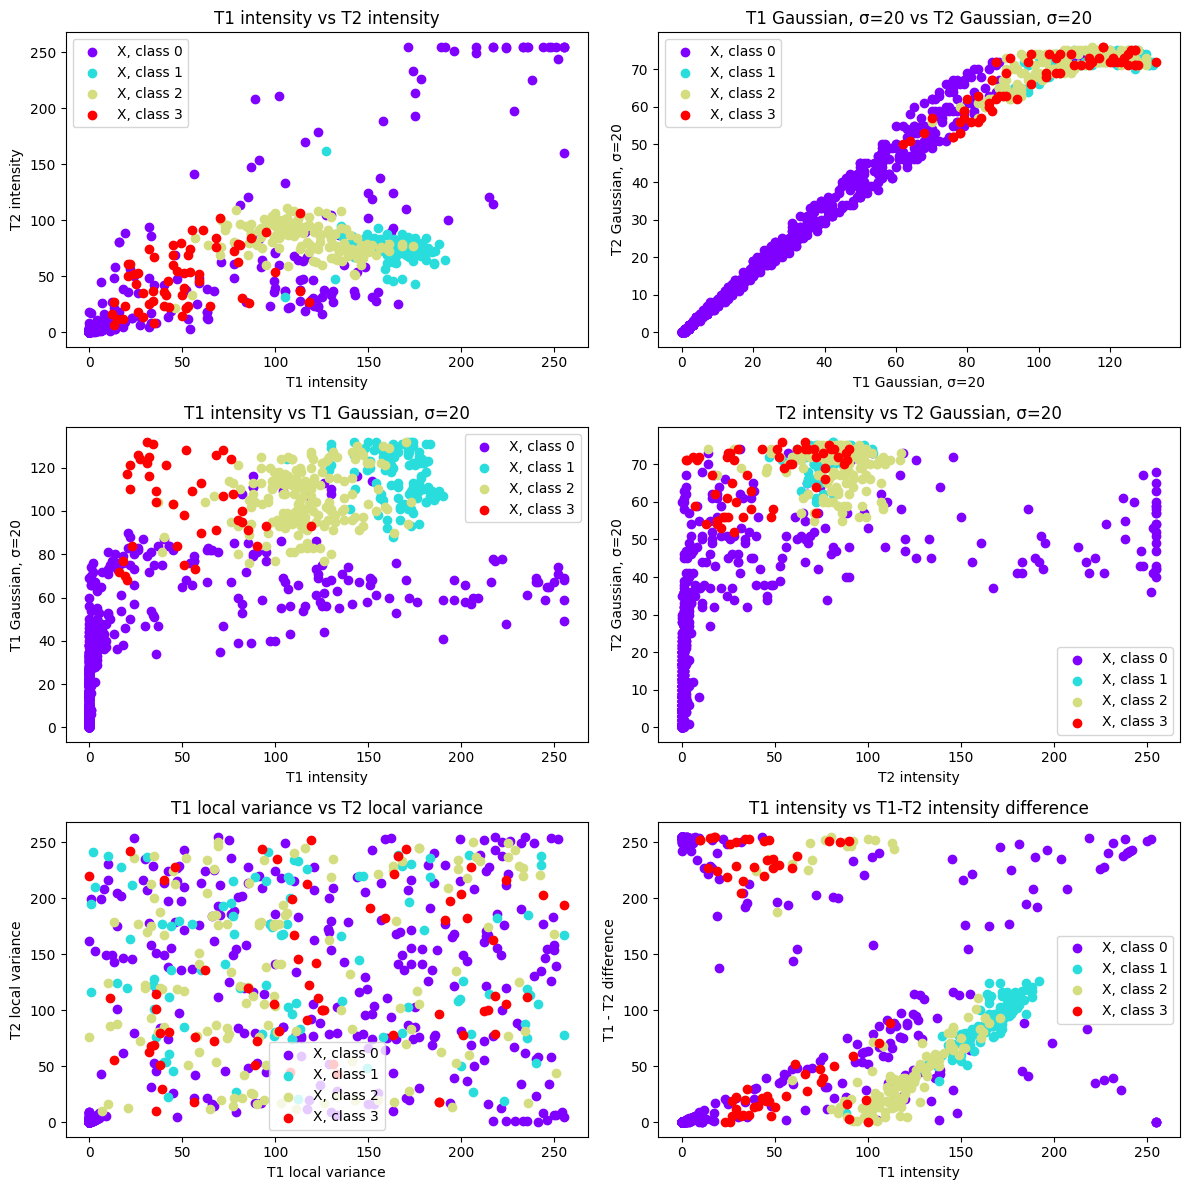

In [ ]:
#1.4
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# compare 0 (T1 intensity) and 1 (T2 intensity) 
util.scatter_data(X_train, y_train, feature0=0, feature1=1, ax=axes[0,0])
axes[0,0].set_xlabel(feature_labels[0])
axes[0,0].set_ylabel(feature_labels[1])
axes[0,0].set_title('T1 intensity vs T2 intensity')
axes[0,0].legend()

# compare 2 (T1 Gaussian, σ=20) against 3 (T2 Gaussian, σ=20) 
util.scatter_data(X_train, y_train, feature0=2, feature1=3, ax=axes[0,1])
axes[0,1].set_xlabel(feature_labels[2])
axes[0,1].set_ylabel(feature_labels[3])
axes[0,1].set_title('T1 Gaussian, σ=20 vs T2 Gaussian, σ=20')
axes[0,1].legend()

# compare 0 (T1 intensity) against 2 (T1 Gaussian, σ=20) 
util.scatter_data(X_train, y_train, feature0=0, feature1=2, ax=axes[1,0])
axes[1,0].set_xlabel(feature_labels[0])
axes[1,0].set_ylabel(feature_labels[2])
axes[1,0].set_title('T1 intensity vs T1 Gaussian, σ=20')
axes[1,0].legend()

# compare 1 (T2 intensity) and 3 (T2 Gaussian, σ=20)
util.scatter_data(X_train, y_train, feature0=1, feature1=3, ax=axes[1,1])
axes[1,1].set_xlabel(feature_labels[1])
axes[1,1].set_ylabel(feature_labels[3])
axes[1,1].set_title('T2 intensity vs T2 Gaussian, σ=20')
axes[1,1].legend()

# compare 4 (T1 local variance, window size = 5) against 5 (T2 local variance, window size = 5)
util.scatter_data(X_train, y_train, feature0=4, feature1=5, ax=axes[2,0])
axes[2,0].set_xlabel(feature_labels[4])
axes[2,0].set_ylabel(feature_labels[5])
axes[2,0].set_title('T1 local variance vs T2 local variance')
axes[2,0].legend()

# compare 0 (T1 intensity) and 6 (T1-T2 intensity difference) 
util.scatter_data(X_train, y_train, feature0=0, feature1=6, ax=axes[2,1])
axes[2,1].set_xlabel(feature_labels[0])
axes[2,1].set_ylabel(feature_labels[6])
axes[2,1].set_title('T1 intensity vs T1-T2 intensity difference')
axes[2,1].legend()

plt.tight_layout()
plt.show()

Training data shape: (57600, 9)
Number of pixels: 57600
Number of features: 9
Features extracted:
0:T1 intensity
1:T2 intensity
2:T1 Gaussian, σ=20
3:T2 Gaussian, σ=20
4:T1 local variance
5:T2 local variance
6:T1 - T2 difference
7:T1 Sobel edge strength
8:T2 Sobel edge strength


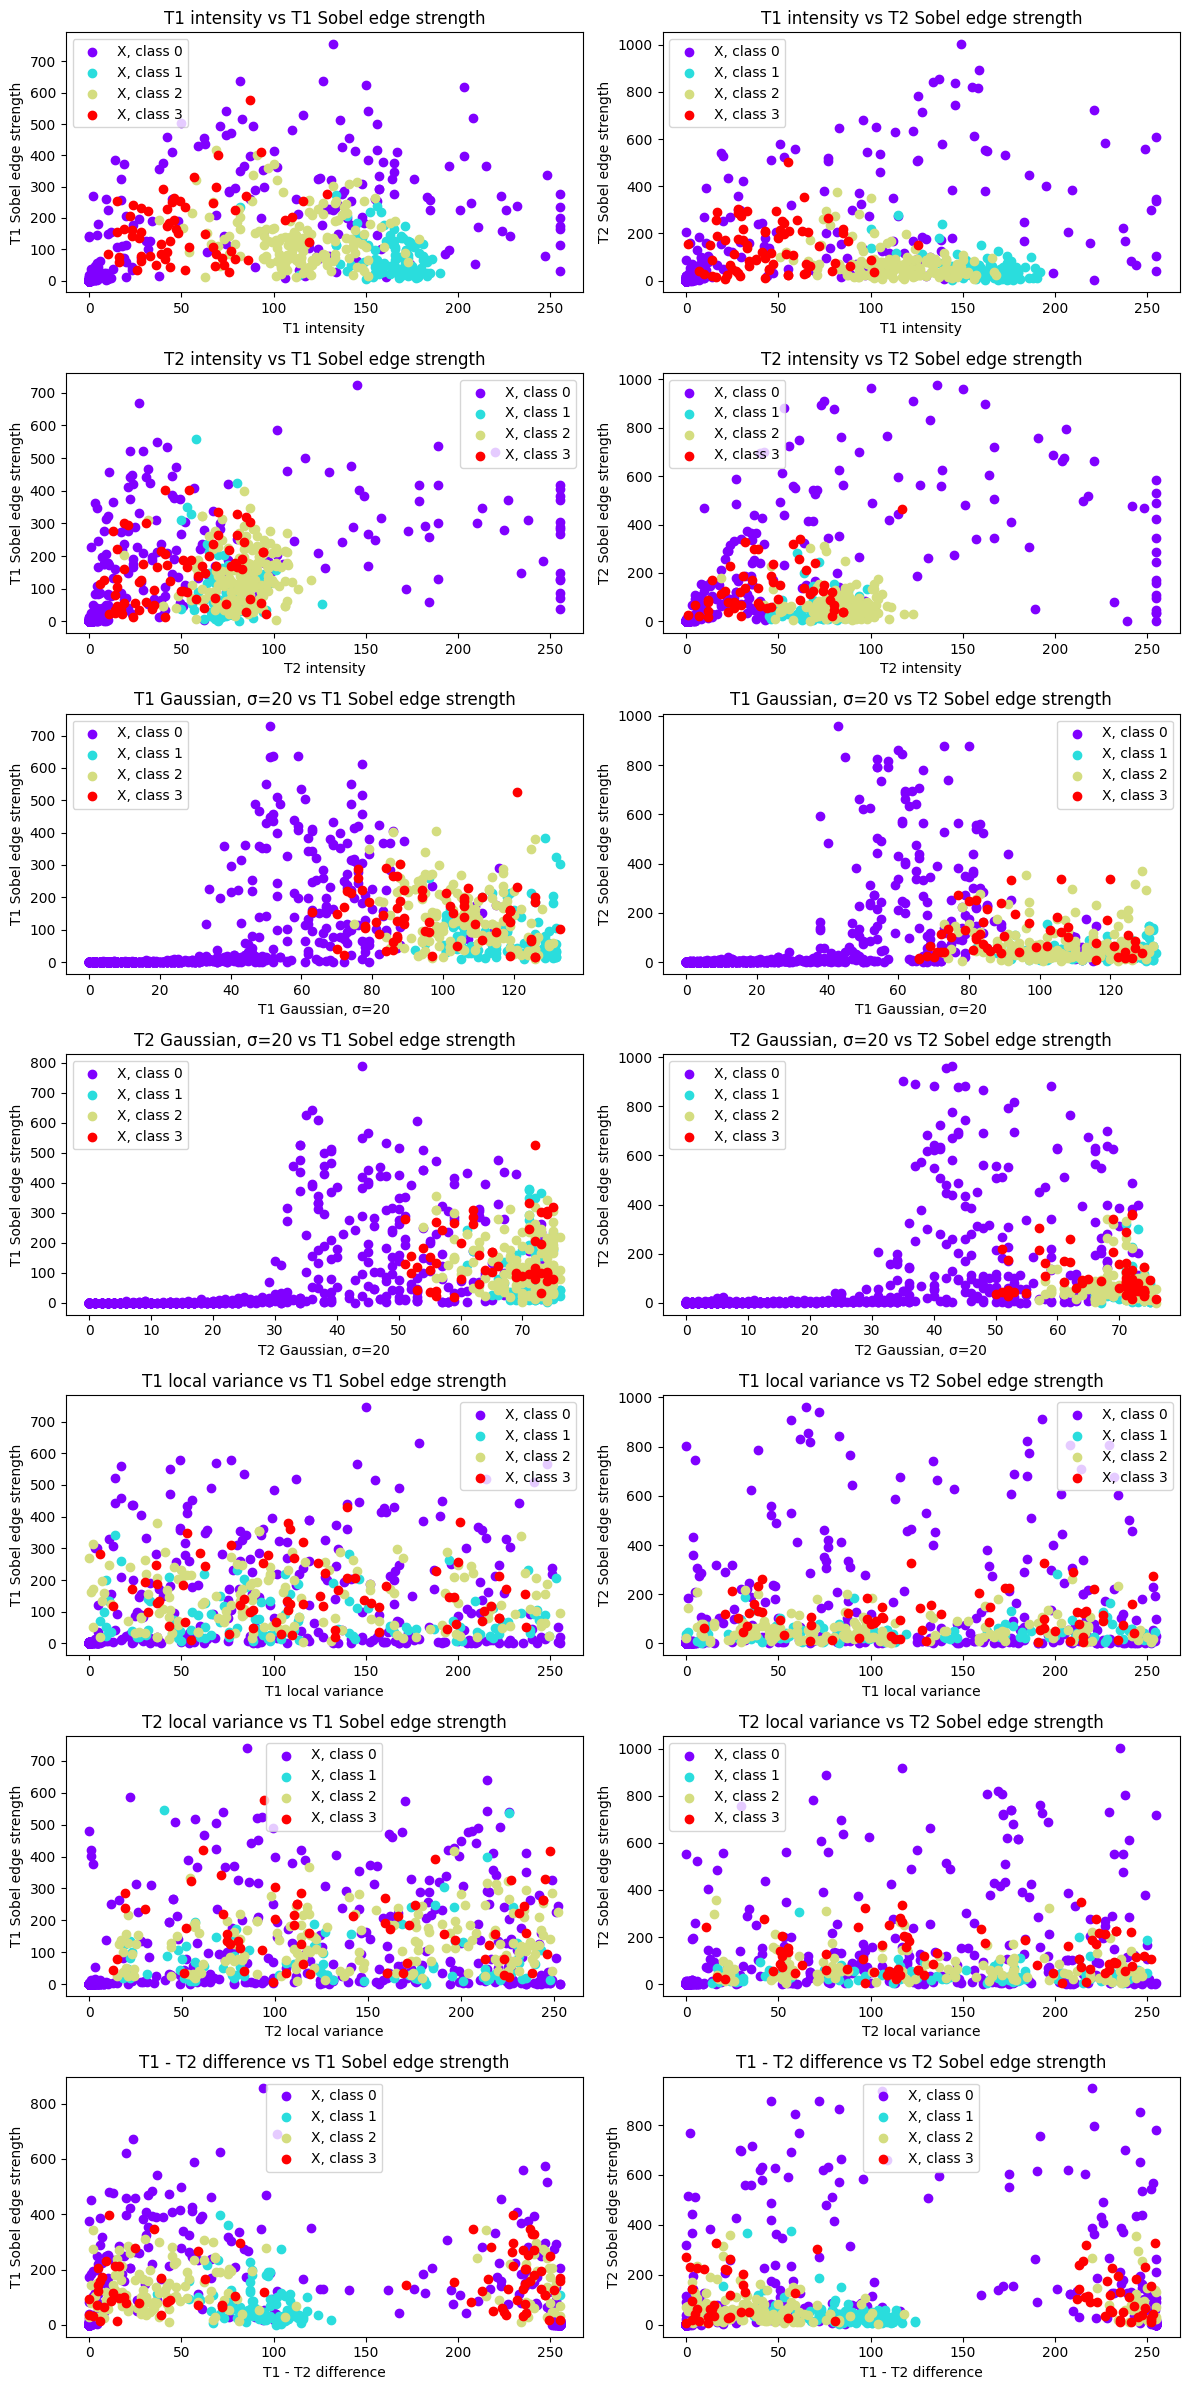

In [44]:
# 1.5 NEW FEATURE: Implement it in a new function with the image as input and the feature vector as output

# TODO ARIANA: 
# DEMONSTRATION SHOWING IT IS DIFFERENT FROM CURRENT FEATURES (e.g. the scatter plot above, or some kind of correlation plot)  
# Choose good plot combination; motivate how it is different from current features

# This feature can be accessed by setting include_edge=True in create_dataset()
train_subject = 1
slice_number = 1
task = 'tissue'

# Re-define X_train_ y_train and feature_labels with edge detection included 
X_train, y_train, feature_labels = util.create_dataset(train_subject, slice_number, task, include_edge=True)

y_train = y_train.ravel()

# Print statements to check that the edge detection features are added to the training data 
print('Training data shape:', X_train.shape)
print('Number of pixels:', X_train.shape[0])
print('Number of features:', X_train.shape[1])
print('Features extracted:')
for i, f in enumerate(feature_labels):
    print(f'{i}:{f}')

# Demonstrate that the new features (T1/T2 Sobel) are different from existing features
fig, axes = plt.subplots(7, 2, figsize=(12, 24))

# Features to compare against: T1, T2, T1 gauss, T2 gauss, T1-T2 diff
compare_features = [0, 1, 2, 3, 4, 5, 6]

for row, feat_idx in enumerate(compare_features):
    # Column 0: T1 Sobel (7) vs comparison feature
    util.scatter_data(X_train, y_train, feature0=feat_idx, feature1=7, ax=axes[row, 0])
    axes[row, 0].set_xlabel(feature_labels[feat_idx])
    axes[row, 0].set_ylabel(feature_labels[7])
    axes[row, 0].set_title(f'{feature_labels[feat_idx]} vs T1 Sobel edge strength')
    axes[row, 0].legend()

    # Column 1: T2 Sobel (8) vs comparison feature
    util.scatter_data(X_train, y_train, feature0=feat_idx, feature1=8, ax=axes[row, 1])
    axes[row, 1].set_xlabel(feature_labels[feat_idx])
    axes[row, 1].set_ylabel(feature_labels[8])
    axes[row, 1].set_title(f'{feature_labels[feat_idx]} vs T2 Sobel edge strength')
    axes[row, 1].legend()

plt.tight_layout()
plt.show()

5. Your answer should include a description of the feature, the code to extract it, and a demonstration that shows it is different from the features you already have.
   
The new feature was an edge detection operator, specifically a Sobel filter (`scipy.ndimage.sobel()`). Besides Sobel, two other edge detection operators were considered: the Prewett operator, and the Canny operator. However, Prewett uses a uniform averaging technique which makes it less accurate than Sobel. While Canny is a more advanced operator, it requires threshold values for pixel brightnesses to be able to classify strong and weak edges. Since this information was not readily available, Sobel was ultimately chosen. The choice of a Sobel filter was also validated by literature.
https://www.sciencedirect.com/science/article/pii/S1877050922004768
https://link.springer.com/article/10.1007/s10462-025-11151-8

The Sobel filter detects how rapidly pixel intensities change across neighbouring pixels. It scans the image pixels across both axes to detect horizontal and vertical edges by computing gradients. Both these results were then combined to find overall edge strengths. Higher values in the feature vector means there is a boundary across which intensity values are changing, whilst lower values mean the area is homogeneous. Two new columns were added to the features matrix: the Sobel filter results applied to the T1 image, and to the T2 image. Both T1 and T2 were used given that the boundary features appear visually different in both. 

Across the comparisons, the Sobel feature showed no strong relationship with the other existing features. For any given value of intensity, Gaussian smoothing, local variance, or T1-T2 difference, it could be seen that the Sobel values for the tissue (white matter, grey matter and CSF) remained low (0-300) with significant scatter. The background and skull showed scatter across the entire Sobel range (0-1000). This compression of the tissue values into a smaller range is not something that appears in the other features being used, and so it provides useful information about distinguishing between the background and the tissue. 

### 2. Model selection and generalization

1. Use the `create_dataset` function to create a training set and a test set for the tissue segmentation task. Use the same slice, but different subjects for training and testing.
2. Use these datasets to investigate using different features and different segmentation methods. You can use both classification error and dice overlap for evaluation, but since now there are four different classes (three tissues and background, you will need to use `dice_multiclass`.
    
    How do you decide what good choices are?  Document this process in a function you create yourself, which returns the best choices given two different subjects.
4. Repeat the above, but use a different subject for testing. Do your conclusions change or stay the same, why? What if you vary the slices? 

In [4]:
# 2.1 CREATE TRAINING + TEST SET FOR TISSUE SEGMENTATION
#     Use a different training and test subject, but the same slice 
train_subject = 1
test_subject = 2
slice_number = 1
task = 'tissue'

# Don't forget to set include_edge=True -> you should get 9 features
X_train, y_train, feature_labels = util.create_dataset(train_subject, slice_number, task, include_edge=True)
X_test, y_test, _ = util.create_dataset(test_subject, slice_number, task, include_edge=True)

y_train = y_train.ravel()
y_test = y_test.ravel()

print(f'Training set: subject {train_subject}, shape {X_train.shape}, (', X_train.shape[0], 'pixels, ', X_train.shape[1], 'features )')
print(f'Test set: subject {test_subject}, shape {X_test.shape}, (', X_test.shape[0], 'pixels, ', X_test.shape[1], 'features )')

Training set: subject 1, shape (57600, 9), ( 57600 pixels,  9 features )
Test set: subject 2, shape (57600, 9), ( 57600 pixels,  9 features )


In [5]:
# 2.2 USE THESE DATASETS TO INVESTIGATE DIFFERENT FEATURES + SEGMENTATION METHODS 
#     USE CLASSIFICATION ERROR + DICE FOR EVALUATION 
#     CREATE A FUNCTION THAT RETURNS THE BEST CHOICE FOR FEATURES + SEGMENTATION METHODS FOR SUBJECT 1 AND 2 

best_fs, best_model, best_err, best_dice, results = util.find_best_segmentation(train_subject=1, test_subject=2)


Results for train subject 1, test subject 2, slice 1
Feature set | Model | Error | Dice
Base features + edges               | SVM (RBF kernel) | 0.1120 | 0.7444
Base features + edges               | kNN k=7         | 0.1158 | 0.7358
Base features + edges               | Random Forest   | 0.1182 | 0.7317
Intenisities only                   | SVM (RBF kernel) | 0.1310 | 0.7296
Base features                       | SVM (RBF kernel) | 0.1176 | 0.7280
Base features                       | kNN k=7         | 0.1185 | 0.7277
Base features                       | Random Forest   | 0.1203 | 0.7262
Intenisities only                   | Random Forest   | 0.1443 | 0.7021
Intenisities only                   | kNN k=7         | 0.1462 | 0.6921
Best choice:
Features: Base features + edges
Model: SVM (RBF kernel)
Error: 0.11203125
Dice: 0.7444224519281155


In [6]:
# 2.3A SAME AS ABOVE, BUT WITH A DIFFERENT SUBJECT

best_fs, best_model, best_err, best_dice, results = util.find_best_segmentation(train_subject=1, test_subject=3)


Results for train subject 1, test subject 3, slice 1
Feature set | Model | Error | Dice
Base features + edges               | SVM (RBF kernel) | 0.1384 | 0.7300
Base features + edges               | Random Forest   | 0.1440 | 0.7207
Base features                       | Random Forest   | 0.1442 | 0.7191
Base features                       | SVM (RBF kernel) | 0.1430 | 0.7143
Base features                       | kNN k=7         | 0.1561 | 0.6991
Base features + edges               | kNN k=7         | 0.1561 | 0.6975
Intenisities only                   | SVM (RBF kernel) | 0.1722 | 0.6952
Intenisities only                   | Random Forest   | 0.1792 | 0.6745
Intenisities only                   | kNN k=7         | 0.1811 | 0.6704
Best choice:
Features: Base features + edges
Model: SVM (RBF kernel)
Error: 0.13836805555555556
Dice: 0.7300222229874593


In [7]:
# 2.3B SAME AS ABOVE, BUT WITH A DIFFERENT SLICE

best_fs, best_model, best_err, best_dice, results = util.find_best_segmentation(train_subject=1, test_subject=2, slice_number=2)


Results for train subject 1, test subject 2, slice 2
Feature set | Model | Error | Dice
Base features + edges               | Random Forest   | 0.0857 | 0.8006
Base features                       | Random Forest   | 0.0870 | 0.7982
Base features + edges               | SVM (RBF kernel) | 0.0886 | 0.7891
Base features + edges               | kNN k=7         | 0.0950 | 0.7750
Base features                       | kNN k=7         | 0.0950 | 0.7722
Base features                       | SVM (RBF kernel) | 0.0955 | 0.7716
Intenisities only                   | SVM (RBF kernel) | 0.1198 | 0.7535
Intenisities only                   | Random Forest   | 0.1252 | 0.7370
Intenisities only                   | kNN k=7         | 0.1255 | 0.7344
Best choice:
Features: Base features + edges
Model: Random Forest
Error: 0.08565972222222222
Dice: 0.8005733392916647


In [22]:
# TODO CECILIA: 
# We are currently using three models: kNN with k=7, SVM and Random Forest, but Linear Regression is also 
# implemented in the function (just commented out.)

# Warning SVM takes a long time to run, so ideally your conclusion is not that we should actually use this one 

# We have already chosen Random Forest as the one we move forward with, so ideally we stick with that unless 
# you're really convinced another option is better -- in that case mention in the group chat asap

# 1 - Motivate the choice of models (based on literature)
#     If you decide SVM is too annoying to work with you can replace it with linear regression
#     but be sure to back up each model choice with literature such that it is clear they are all sufficiently different 

# 2 - Do a full analysis of the results of 2.2  (train_subject=1, test_subject=2, slice=1)
#                                          2.3A (train_subject=1, test_subject=3, slice=1)
#                                          2.3B (train_subject=1, test_subject=2, slice=2)
#     Such that it is clear why we choose for Random Forest as the final model and Base Features + Edges as the final feature set
#     Full analysis ideally means you run each question ~5 times and find the mean and st dev of the errors and Dice scores 
#     Remember that when you compare raw scores you should look at relative difference -- a difference of e.g. 0.005 in Dice score 
#     is basically nothing 
#     Put your analysis in a table such that we can reference the table in the report to say "Based on this we chose Random Forest
#     and Base Features + Edges 

### 3. Combining different methods

1. Try the function `segmentation_combined_knn` on the tissue segmentation task (do not forget to combine the labels - look into e.g. majority voting). 
2. Design a method that combines (some) other methods you have learnt so far in `segmentation_mymethod`. Provide a motivation (based on what you know about the methods) of the choices that you made.
3. The script `segmentation_demo`, creates the results for several methods. This code is a bit slow, so it is not recommended to run it multiple times. (Also, you should not use all of these results to improve your method, since that means you are using the test data as the training data :) ). 
4. Run the script and look at the results. How does your method compare to the individual results? It is not required here that your method is always better! For example, you could select a subject where your method is the best, and a subject where your method is the worst, and explain what is happening in the images.
5. Discuss what other (combinations) methods could be suitable or not suitable for the task and why.

In [ ]:
# 3.1 TRY segmentation_combined_knn 

# Create training data from multiple subjects
train_subjects = [1, 2, 3, 4]
test_subject = 5
slice_number = 1
task = "tissue"

data_list = []
label_list = []

for sub in train_subjects:
    X_sub, y_sub, _ = util.create_dataset(sub, slice_number, task)
    data_list.append(X_sub)
    label_list.append(y_sub.ravel())

train_data_matrix = np.stack(data_list, axis=2)
train_labels_matrix = np.stack(label_list, axis=1)

test_data, test_labels, _ = util.create_dataset(test_subject, slice_number, task)
test_labels = test_labels.ravel()

# Test different k values
k_values = [1, 8, 16]

for k in k_values:

    pred = seg.segmentation_combined_knn(
        train_data_matrix,
        train_labels_matrix,
        test_data,
        k=k
    )

    err = util.classification_error(test_labels, pred)

    print(f"k = {k}")
    print(f"Error = {err:.4f}")

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(test_labels.reshape(240, 240))
    plt.title("Ground truth")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(pred.reshape(240, 240))
    plt.title(f"Prediction (k={k})")
    plt.axis("off")

    plt.show()

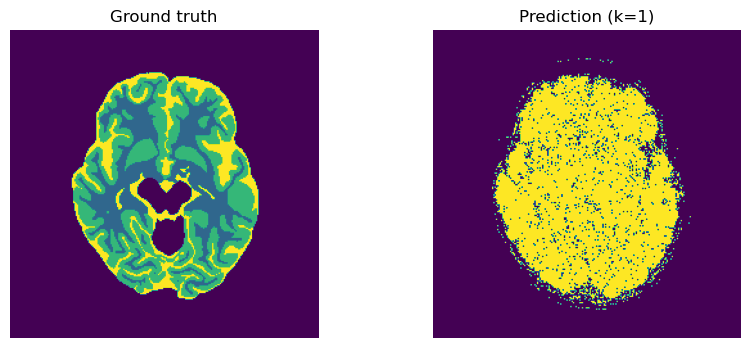

k = 8
Error = 0.2449

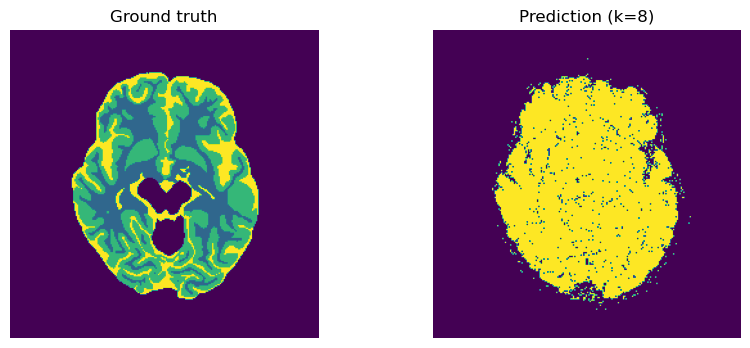

k = 16
Error = 0.2450

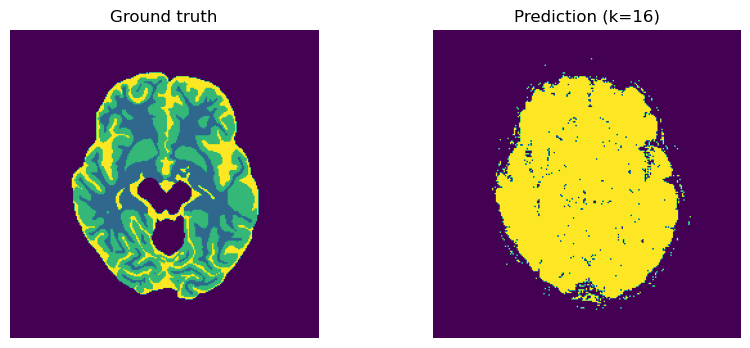

### 3.1 Interpretation

The combined kNN method combines predictions from several training subjects using majority voting. This makes the final prediction less dependent on one individual training subject.

The value of `k` controls how local or smooth the prediction is. With `k=1`, the prediction is based on the single closest training pixel. This can preserve detail, but it can also be noisy. With larger values such as `k=8` or `k=16`, the prediction becomes smoother because more neighbours are used. This may reduce isolated errors, but it can also blur boundaries or remove smaller tissue regions.

Therefore, the best `k` should be chosen based on both the Dice score and the visual comparison between the predicted mask and the ground truth. A higher Dice score is good, but the segmentation should also still make anatomical sense when looking at the masks.

My method on tissue task
Error: 0.32227430555555553
Dice: 0.32344858477288485


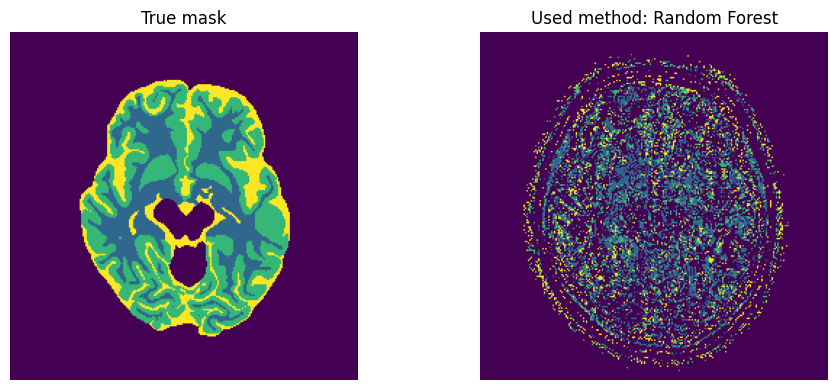

In [ ]:
# 3.2
train_subjects = [1, 2, 3, 4]
test_subject = 5
slice_number = 1

data_list = []
label_list = []
for sub in train_subjects:
    X_sub, y_sub, _ = util.create_dataset(sub, slice_number, 'tissue', include_edge=True)
    data_list.append(X_sub)
    label_list.append(y_sub.ravel())

train_data_matrix = np.stack(data_list, axis=2)
train_labels_matrix = np.stack(label_list, axis=1)

X_te, y_te, _ = util.create_dataset(test_subject, slice_number, 'tissue', include_edge=True)
y_te = y_te.ravel()

pred_my = project.segmentation_mymethod(train_data_matrix, train_labels_matrix, X_te, task='tissue')

err_my = util.classification_error(y_te, pred_my)
dice_my = util.dice_multiclass(y_te.reshape(-1,1), pred_my.reshape(-1,1))

print('My method on tissue task')
print('Error:', err_my)
print('Dice:', dice_my)

util.show_segmentation(y_te, pred_my, title='Used method: Random Forest')

### 3.2 Motivation for Random Forest

We use a Random Forest classifier in `segmentation_mymethod()` because it fits the tissue segmentation task well. The task is multiclass: every pixel has to be classified as background, white matter, gray matter or CSF. Random Forest can handle multiclass classification directly.

Another reason is that the relation between image features and tissue labels is probably not purely linear. A tissue label may depend on a combination of T1 intensity, T2 intensity, smoothed intensity, local texture and edge information. Random Forest can learn non-linear combinations of these features, which makes it more flexible than a simple linear classifier.

Random Forest is also less sensitive to feature scaling than distance-based methods such as kNN. In kNN, features with larger numerical ranges can dominate the distance calculation if the data is not normalized properly. Random Forest uses decision trees, so it is less directly affected by this issue.

Finally, Random Forest combines many decision trees. This usually makes the prediction more robust than using one single decision tree. A limitation is that the method still classifies pixels independently, so it does not explicitly enforce spatial smoothness or anatomical consistency.

Loading data for 5 subjects...
Finished loading data.
Starting segmentation...


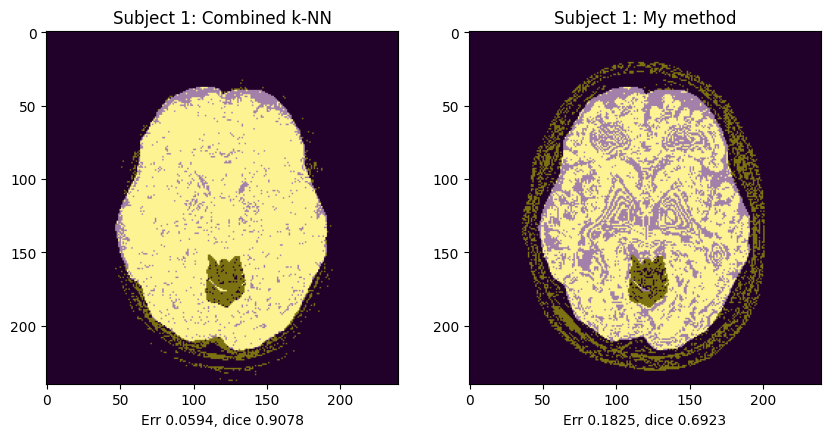

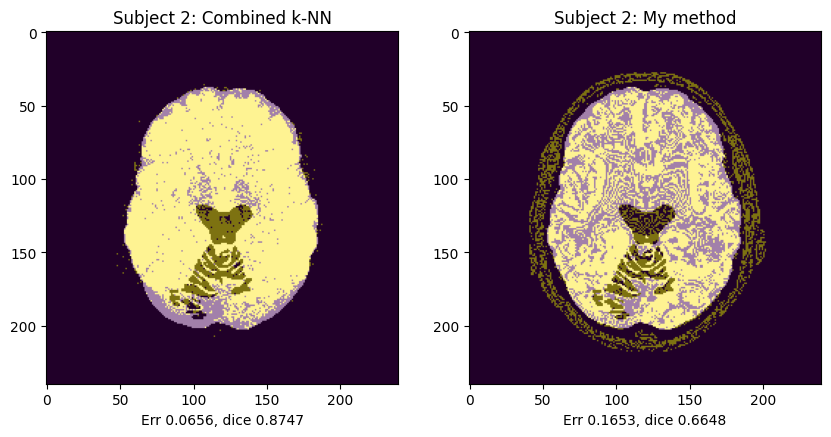

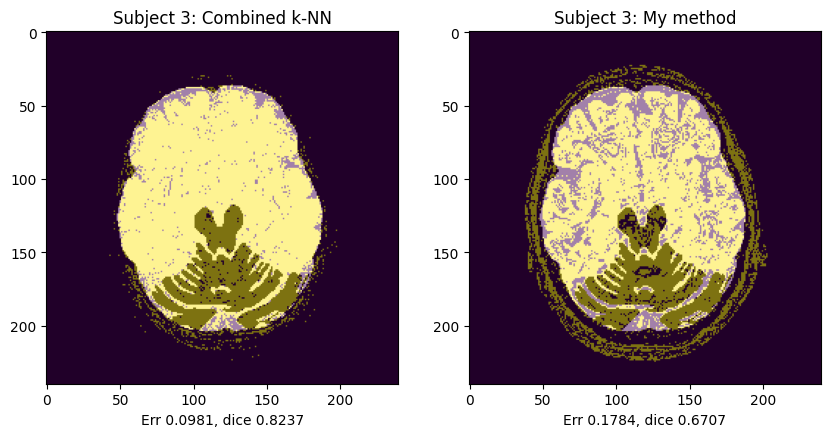

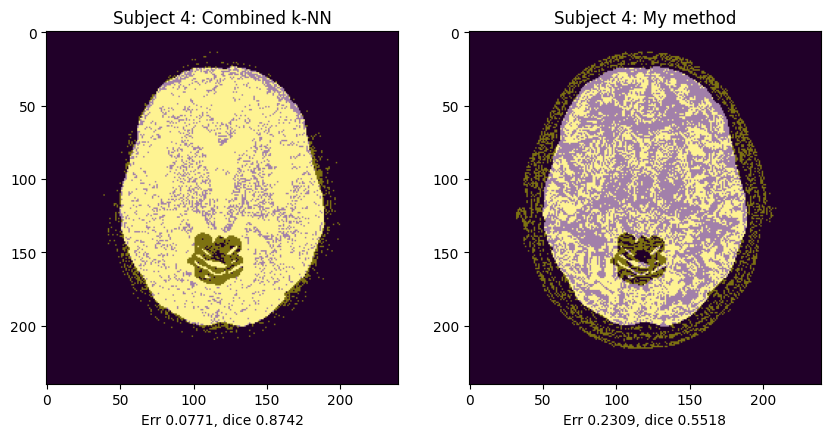

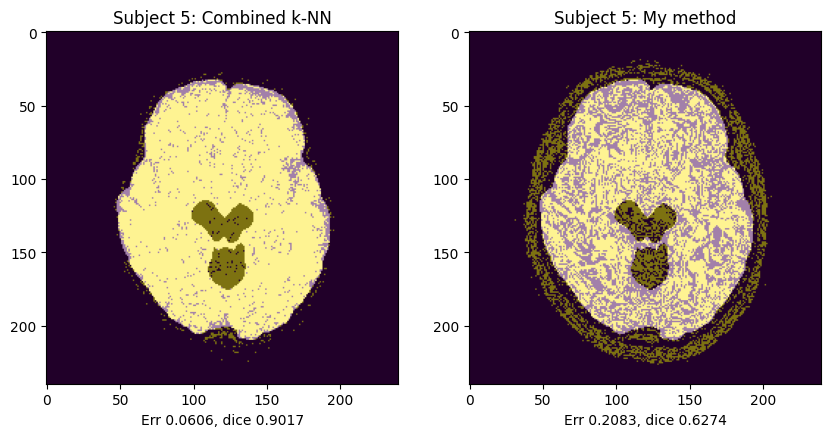

In [37]:
%matplotlib inline
import sys
sys.path.append("../code")
from segmentation_project import segmentation_demo
segmentation_demo()

### 3.3/3.4 Run segmentation_demo() + compare results

The combined kNN method and our method use the training data in different ways. In the combined kNN approach, the predicted label of a test pixel is based on the labels of similar pixels from the training subjects. The method is therefore based on the distances in the feature space and directly uses the training examples during prediction. Our method uses a Random Forest classifier. This method first learns decision rules from the training data and then applies these learned rules to classify the test pixels

Looking at the results, the combined kNN method performs better than our method for all five subjects. It gives lower classification errors and higher Dice score in every case. This is also visible in the segmentation images. The combined kNN results are smoother and follow the true mask more closely, while our method produces more noisy predictions and predicts extra pixels around the outer brain boundary which shouldn't be included. The best case for our method is subject 1, where it reaches its highest Dice score of 0.6923. However, even in this case, combined kNN performs better with a Dice score of 0.9078. The worst case for our method is subject 4, where the Dice score drops to 0.5518 and the error increases to 0.2309.

Overall, our method does not outperform the combined kNN method. Random Forest should in theory be useful because it can learn non-linear relations between features, but it seems to generalise less well to these unseen subjects. Combined kNN appears more stable in this experiment, probably because it directly compares test pixels to similar examples from the other training subjects.

In [26]:
# 3.5 DISCUSS WHAT OTHER COMBINATIONS WOULD BE SUITABLE FOR THIS TASK AND WHY 

# TODO CECILIA:
# Discuss what other (combinations) methods could be suitable or not suitable for the task and why.

## Open-ended project work

Define and motivate one research question that you will investigate. This can be a question relating to a method (e.g. what is the impact of X on a particular method) or relating to the problem (e.g. does a specific method fail in specific cases). It can be based on what you have done above or take another direction.
It is recommended to get feedback on your research question from the teaching assistants.

### Research question

How does adding edge detection as an extra feature impact the results of segmentation, and is there a specific tissue that benefits most from this?

### Hypothesis 

We expect that adding edge detection will make the boundaries of CSF more sharp, since this is a higher contrast difference than the difference between WM/GM.

### Study design

Data, features, models, etc

### Methods
- Comparison of the predicted mask, with and without edge features
- Comparison of the confusion matrix, with and without edge features
- Comparison of overall error and Dice score, with and without edge features
- Comparison of tissue-specific Dice score, with and without edge features
- Comparison learning curves using increasing pixel samples, with and without edge features

In [24]:
# TODO ARIANA:
# Implementing the above analysis metrics + write up of discussion

# Set up datasets for analysis 
train_subject = [1, 2, 3, 4]
test_subject = 5
slice_number = 1

task = 'tissue'
tissue_names = {0: 'Background', 1: 'White matter', 2: 'Grey matter', 3: 'CSF'}

base_features = [0, 1, 2, 3, 4, 5, 6] # feature columns excluding edge detection 
edge_features = [0, 1, 2, 3, 4, 5, 6, 7, 8]  # feature columns including edge detection 

model = RandomForestClassifier(n_estimators=100, min_samples_leaf=2, random_state=0, n_jobs=-1)

# Set up training and test datasets
data_list, label_list = [], []

for sub in train_subject:
    X_sub, y_sub, _ = util.create_dataset(sub, slice_number, 'tissue', include_edge=True)
    data_list.append(X_sub)
    label_list.append(y_sub.ravel())

X_train = np.concatenate(data_list, axis=0)
y_train = np.concatenate(label_list, axis=0)

X_test, y_test, _ = util.create_dataset(test_subject, slice_number, 'tissue', include_edge=True)
y_test = y_test.ravel()

# Evaluate the base feature set in general (without edge features) and per class 
base_err, base_dice, base_y_pred = util.evaluate_model(model, X_train[:,base_features], y_train, X_test[:,base_features], y_test)
base_dice_class = util.dice_per_class(y_test, base_y_pred)

# Evaluate the new feature set (with edge features)
edge_err, edge_dice, edge_y_pred = util.evaluate_model(model, X_train, y_train, X_test, y_test)
edge_dice_class = util.dice_per_class(y_test, edge_y_pred)

A training data set was first put together using subjects 1-4, with subject 5 being used as the test. The training and test sets were then evaluated for the base features, and then the base features in addition to the edge features. From this, comparisons could be drawn on the impact of including the edge features. 

#### Impact of sample pixels on Dice scores

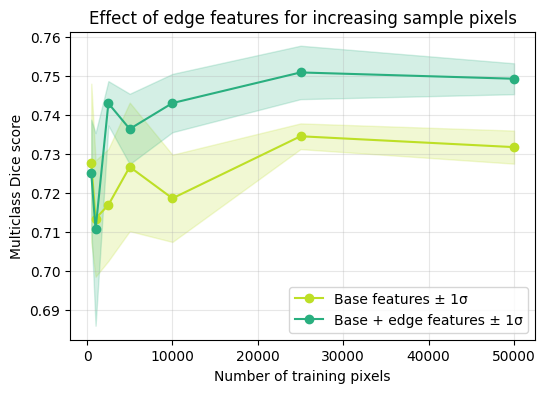

In [45]:
# LEARNING CURVE

# Set up number of pixel samples to train data on 
sample_sizes = [500, 1000, 2500, 5000, 10000, 25000, 50000]
model_fn = lambda: RandomForestClassifier(n_estimators=100, min_samples_leaf=2, random_state=0, n_jobs=-1)

# Find mean and st dev of the dice scores per sample size
# base_dice_mean, base_dice_std = util.learning_curve_dice(X_train, y_train, X_test, y_test, base_features, sample_sizes, model_fn)
# edge_dice_mean, edge_dice_std = util.learning_curve_dice(X_train, y_train, X_test, y_test, edge_features, sample_sizes, model_fn)

# store the results used for the analysis to get the same graph each time 
base_dice_mean = np.array([0.72768483, 0.71346939, 0.71693539, 0.72667857, 0.71863654, 0.73450654, 0.73173066])
base_dice_std  = np.array([0.02025637, 0.01487587, 0.0143132,  0.01643127, 0.01114718, 0.00328862, 0.00422612])
edge_dice_mean = np.array([0.72502185, 0.7106889,  0.74293323, 0.73637397, 0.74299179, 0.75082492, 0.7492132 ])
edge_dice_std  = np.array([0.01372066, 0.02462196, 0.0056706,  0.00899584, 0.0074566,  0.00683119, 0.0039523 ])

# Plot Dice scores against n_samples 
plt.figure(figsize=(6,4))
# Curve with no edge features
plt.plot(sample_sizes, base_dice_mean, marker='o', label='Base features ± 1σ', color='#bddf26')
plt.fill_between(sample_sizes,
                 base_dice_mean - base_dice_std,
                 base_dice_mean + base_dice_std,
                 alpha=0.2, color='#bddf26')
# Curve with edge features
plt.plot(sample_sizes, edge_dice_mean, marker='o', label='Base + edge features ± 1σ', color='#29af7f')
plt.fill_between(sample_sizes,
                 edge_dice_mean - edge_dice_std,
                 edge_dice_mean + edge_dice_std,
                 alpha=0.2, color='#29af7f')
plt.xlabel('Number of training pixels')
plt.ylabel('Multiclass Dice score')
plt.title('Effect of edge features for increasing sample pixels')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('Learning curve', dpi=500)
plt.show()

In [26]:
print('base_dice_mean:', base_dice_mean)
print('base_dice_std:', base_dice_std)
print('edge_dice_mean:', edge_dice_mean)
print('edge_dice_std:', edge_dice_std)

base_dice_mean: [0.72768483 0.71346939 0.71693539 0.72667857 0.71863654 0.73450654
 0.73173066]
base_dice_std: [0.02025637 0.01487587 0.0143132  0.01643127 0.01114718 0.00328862
 0.00422612]
edge_dice_mean: [0.72502185 0.7106889  0.74293323 0.73637397 0.74299179 0.75082492
 0.7492132 ]
edge_dice_std: [0.01372066 0.02462196 0.0056706  0.00899584 0.0074566  0.00683119
 0.0039523 ]


A learning curve was created to assess whether the Dice score improvement from adding edge features depended on the amount of subsambled training pixels available. The subsampling ranged from 500 to 50000 pixels, and was repeated 5 times per sample size to account for variability from random pixel selection. 

It was found that at low pixel samples (500-1000), the two feature sets (with and without edge detection) performed similarly. The mean Dice scores were similar, and the standard deviations had significant overlap. However, from 2500 px onwards the edge feature began showing a clear advantage. From 10000 px onwards, the edge feature set consistently performed better than the base feature set. The standard deviations for each set also stopped overlapping from here. After 25000 px both curves stabilised, indicating that this many samples is sufficient for reliable comparison of performance. 

From this, it can be seen that a conclusion on edge features improving Dice scores can be drawn after 10000 sample pixels. From here, there is a consistent improvement in performance when edge features are used and low variance. This suggests that the baseline feature set cannot learn boundary information simply from providing more pixel sample data, as the two feature curves never converge. Hence, we can conclude that adding edge features provides new information to the segmentation process.

#### Dice scores and classification errors

In [27]:
# CHANGE IN DICE SCORES WITH AND WITHOUT EDGE DETECTION 

# Print results for overall error and Dice score
print(f'Results: train subject {train_subject}, test subject {test_subject}, slice {slice_number}')
print(f'{"Metric":20s} | {"Without edge":>12s} | {"With edge":>12s} | {"Difference":>10s}')
print('-' * 62)
print(f'{"Classification error":20s} | {base_err:12.2f} | {edge_err:12.2f} | {edge_err - base_err:+10.2f}')
print(f'{"Dice score":20s} | {base_dice:12.2} | {edge_dice:12.2f} | {edge_dice - base_dice:+10.2f}')
print('-' * 62)
# Print results for Dice score per tissue class
print('Tissue-specific Dice scores')
for class_name in base_dice_class:
    base_dice = base_dice_class[class_name]
    edge_dice = edge_dice_class[class_name]
    print(f'{class_name:20s} | {base_dice:12.2f} | {edge_dice:12.2f} | {edge_dice - base_dice:+10.2f}')    

Results: train subject [1, 2, 3, 4], test subject 5, slice 1
Metric               | Without edge |    With edge | Difference
--------------------------------------------------------------
Classification error |         0.13 |         0.12 |      -0.01
Dice score           |         0.73 |         0.75 |      +0.02
--------------------------------------------------------------
Tissue-specific Dice scores
Background           |         0.96 |         0.97 |      +0.00
White matter         |         0.61 |         0.63 |      +0.03
Gray matter          |         0.72 |         0.73 |      +0.02
CSF                  |         0.65 |         0.68 |      +0.04


Dice scores and classification errors were also compared. The overall classification error showed a modest decrease of 0.01 whilst the overall Dice score showed an increase of 0.02 when adding edge detection to the feature set. However, as this research was on tissue-specific effects, tissue-specific Dice scores were also evaluated. It can be seen that every tissue class's Dice score improved from adding the edge feature. The background showed the least improvement, but it already had a nearly perfect segmentation. The CSF score increased the most (0.04), followed by white matter (0.03) and then grey matter (0.02). This shows there was a consistent improvment in segmentation of all tissue types, rather than an improvement of one at the expense of the other, suggesting that the edge feature benefitted all the tissue to some extent. The largest increase being CSF agrees with the hypothesis that tissues with the sharpest intensity boundaries in MRI would benefit the most from the edge detection feature, as CSF has a sharp contrast in both T1 and T2 images. 

#### Predicted masks

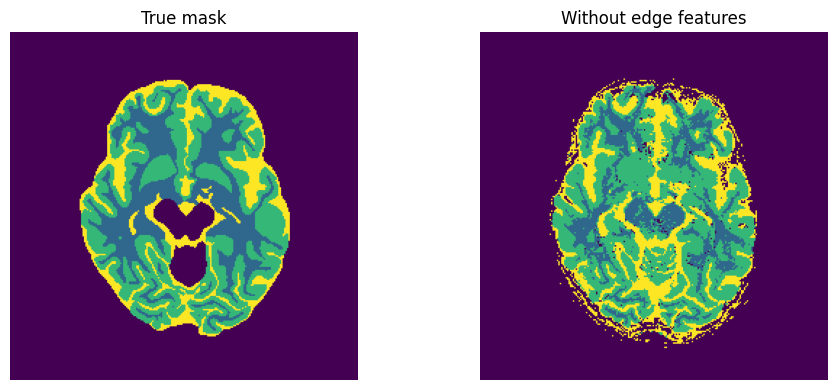

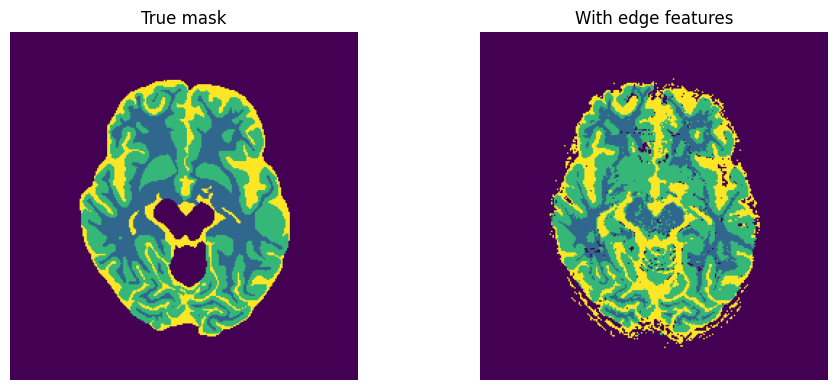

In [28]:
# Plot base feature mask against true mask
util.show_segmentation(y_test, base_y_pred, title="Without edge features")

# Plot edge feature mask against true mask
util.show_segmentation(y_test, edge_y_pred, title="With edge features")

Fixed by adding edge features: 1307 pixels
Broken by adding edge features: 728 pixels
Changed but still wrong: 357 pixels
Total changed: 2392 pixels


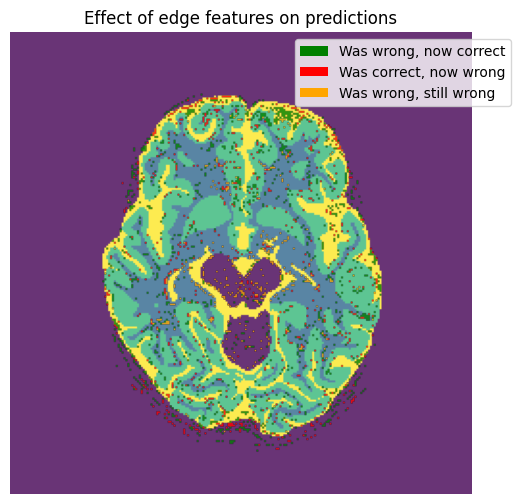

In [35]:
true_labels = y_test

# Categorise each pixel based on whether it was correctly predicted or not
base_correct = (base_y_pred == true_labels)
edge_correct = (edge_y_pred == true_labels)

# Pixels where prediction changed
changed = (base_y_pred != edge_y_pred)

# Category 1: was wrong, now correct -> edge features FIXED this px
fixed = changed & (~base_correct) & edge_correct

# Category 2: was correct, now wrong -> edge features BROKE this px
broken = changed & base_correct & (~edge_correct)

# Category 3: changed but still wrong (different wrong tissue/bg categorisation)
still_wrong = changed & (~base_correct) & (~edge_correct)

print(f'Fixed by adding edge features: {np.sum(fixed)} pixels')
print(f'Broken by adding edge features: {np.sum(broken)} pixels')
print(f'Changed but still wrong: {np.sum(still_wrong)} pixels')
print(f'Total changed: {np.sum(changed)} pixels')

# Build a categorical map for visualisation
category_map = np.zeros(true_labels.shape)  # 0 = unchanged
category_map[fixed] = 1
category_map[broken] = 2
category_map[still_wrong] = 3

category_map = category_map.reshape(240, 240)
true_mask = true_labels.reshape(240, 240)


cmap = ListedColormap(['none', 'green', 'red', 'orange'])
norm = BoundaryNorm([0, 1, 2, 3, 4], cmap.N)

plt.figure(figsize=(6,6))
plt.imshow(true_mask, alpha=0.8)
plt.imshow(category_map, cmap=cmap, norm=norm, alpha=0.8)
plt.title('Effect of edge features on predictions')
plt.axis('off')

legend_elements = [
    Patch(facecolor='green', label='Was wrong, now correct'),
    Patch(facecolor='red', label='Was correct, now wrong'),
    Patch(facecolor='orange', label='Was wrong, still wrong'),
]
plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.1, 1))
plt.savefig('difference_map.png', dpi=500)
plt.show()

In [30]:
# Per-tissue breakdown of pixel reassignments
print(f'\n{"Tissue":15s} | {"Fixed":>8s} | {"Broken":>8s} | {"Still wrong":>11s} | {"Total changed":>13s} | {"Net effect":>10s}')
print('-' * 80)

for c, name in tissue_names.items():
    tissue_mask = (true_labels == c)
    
    n_fixed       = np.sum(fixed & tissue_mask)
    n_broken      = np.sum(broken & tissue_mask)
    n_still_wrong = np.sum(still_wrong & tissue_mask)
    n_changed     = np.sum(changed & tissue_mask)
    net           = n_fixed - n_broken

    # Format net effect with + or - sign and a direction label
    net_str = f'{net:+d} ({"↑" if net > 0 else "↓" if net < 0 else "="})' 
    
    print(f'{name:15s} | {n_fixed:8d} | {n_broken:8d} | {n_still_wrong:11d} | {n_changed:13d} | {net_str:>10s}')

print('-' * 80)
net_total = np.sum(fixed) - np.sum(broken)
net_total_str = f'{net_total:+d} ({"↑" if net_total > 0 else "↓" if net_total < 0 else "="})'
print(f'{"Total":15s} | {np.sum(fixed):8d} | {np.sum(broken):8d} | {np.sum(still_wrong):11d} | {np.sum(changed):13d} | {net_total_str:>10s}')


Tissue          |    Fixed |   Broken | Still wrong | Total changed | Net effect
--------------------------------------------------------------------------------
Background      |      296 |      146 |         130 |           572 |   +150 (↑)
White matter    |      343 |      164 |         177 |           684 |   +179 (↑)
Grey matter     |      324 |      264 |          45 |           633 |    +60 (↑)
CSF             |      344 |      154 |           5 |           503 |   +190 (↑)
--------------------------------------------------------------------------------
Total           |     1307 |      728 |         357 |          2392 |   +579 (↑)


In [31]:
# Normalised per-tissue breakdown of pixel reassignments
print(f'\n{"Tissue":15s} | {"Fixed":>8s} | {"Broken":>8s} | {"Still wrong":>11s} | {"Total changed":>13s} | {"Net effect":>12s}')
print('-' * 85)

for c, name in tissue_names.items():
    tissue_mask   = (true_labels == c)
    n_tissue      = np.sum(tissue_mask)  # total pixels of this tissue

    n_fixed       = np.sum(fixed & tissue_mask)
    n_broken      = np.sum(broken & tissue_mask)
    n_still_wrong = np.sum(still_wrong & tissue_mask)
    n_changed     = np.sum(changed & tissue_mask)
    net           = (n_fixed - n_broken) / n_tissue * 100

    net_str = f'{net:+.2f}% ({"↑" if net > 0 else "↓" if net < 0 else "="})'

    # normalise fixed, broken, still_wrong net effect
    print(f'{name:15s} | '
          f'{n_fixed/n_tissue*100:7.2f}% | '
          f'{n_broken/n_tissue*100:7.2f}% | '
          f'{n_still_wrong/n_tissue*100:10.2f}% | '
          f'{n_changed/n_tissue*100:12.2f}% | '
          f'{net_str:>12s}')

print('-' * 85)
# Total row normalised by all pixels
n_total = len(true_labels)
net_total = (np.sum(fixed) - np.sum(broken)) / n_total * 100
net_total_str = f'{net_total:+.2f}% ({"↑" if net_total > 0 else "↓" if net_total < 0 else "="})'
print(f'{"Total":15s} | '
      f'{np.sum(fixed)/n_total*100:7.2f}% | '
      f'{np.sum(broken)/n_total*100:7.2f}% | '
      f'{np.sum(still_wrong)/n_total*100:10.2f}% | '
      f'{np.sum(changed)/n_total*100:12.2f}% | '
      f'{net_total_str:>12s}')


Tissue          |    Fixed |   Broken | Still wrong | Total changed |   Net effect
-------------------------------------------------------------------------------------
Background      |    0.75% |    0.37% |       0.33% |         1.44% |   +0.38% (↑)
White matter    |    6.29% |    3.01% |       3.25% |        12.55% |   +3.28% (↑)
Grey matter     |    3.82% |    3.11% |       0.53% |         7.45% |   +0.71% (↑)
CSF             |    8.74% |    3.91% |       0.13% |        12.77% |   +4.82% (↑)
-------------------------------------------------------------------------------------
Total           |    2.27% |    1.26% |       0.62% |         4.15% |   +1.01% (↑)


First, the predicted mask without using edge features was compared to the ground truth mask. This prediction struggled with capturing the CSF/skull boundary in some areas, and struggled with differentiating white matter from grey matter in the centre of the brain. Furthermore, distinguishing all tissue types from background towards the centre and bottom of the brain was clearly difficult. With adding edge-detection features to the dataset, the hypothesis was that CSF would be more identifiable given that there is a larger change in contrast between CSF and other tissue.

After adding edge features to the training dataset and creating a new predicted mask, a total of 2392 pixel labels were reassigned (4.15% of all pixels in the image). A difference plot was created where the changed pixels were overlaid on the ground truth mask. This can be seen in tissue-specific detail in Table X. Background pixels were least affected, with a net improvement of +0.38%. This makes sesne, given that the bulk of these pixels are far from any tissue boundary. White matter showed a net improvement of +3.28%, but also had a relatively high proportion of still wrong pixels (3.25%), suggesting that there could still be some improvement with its segmentation. Grey matter a relatively small improvement of +0.71%, but the proportion of fixed and broken pixels are roughly the same, suggesting the edge detection had a mixed effect here. 

The largest improvement was seen in the CSF prediction, where 8.74% of wrongly classified pixels were fixed and there was a net improvement of +4.82%. It also had the lowest proportion of still wrong pixels at 0.13%, which means when the edge feature changes a CSF prediction it was almost always correct. This supports the hypothesis that CSF benefits the most from adding edge detection as a feature, due to its sharp intensity boundaries.

#### Confusion matrix

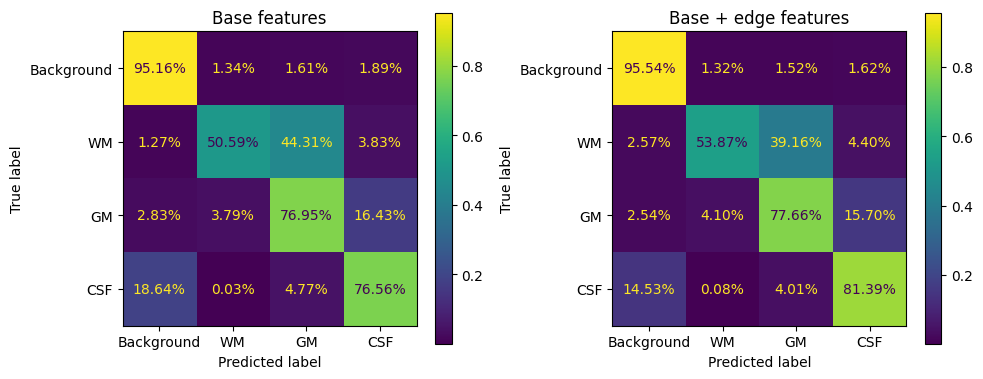

In [46]:
# CONFUSION MATRIX

# set up plots with each tissue type 
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = ['Background', 'WM', 'GM', 'CSF']

# set up confusion matrix 
base_CM = confusion_matrix(y_test, base_y_pred, normalize='true')
edge_CM = confusion_matrix(y_test, edge_y_pred, normalize='true')

# show the normalised matrix for the base features 
ConfusionMatrixDisplay(base_CM, display_labels=labels).plot(ax=axes[0], values_format='.2%')
axes[0].set_title('Base features')

# show the normalised matrix for the base+edge features
ConfusionMatrixDisplay(edge_CM, display_labels=labels).plot(ax=axes[1], values_format='.2%')
axes[1].set_title('Base + edge features')

plt.tight_layout()
plt.show()

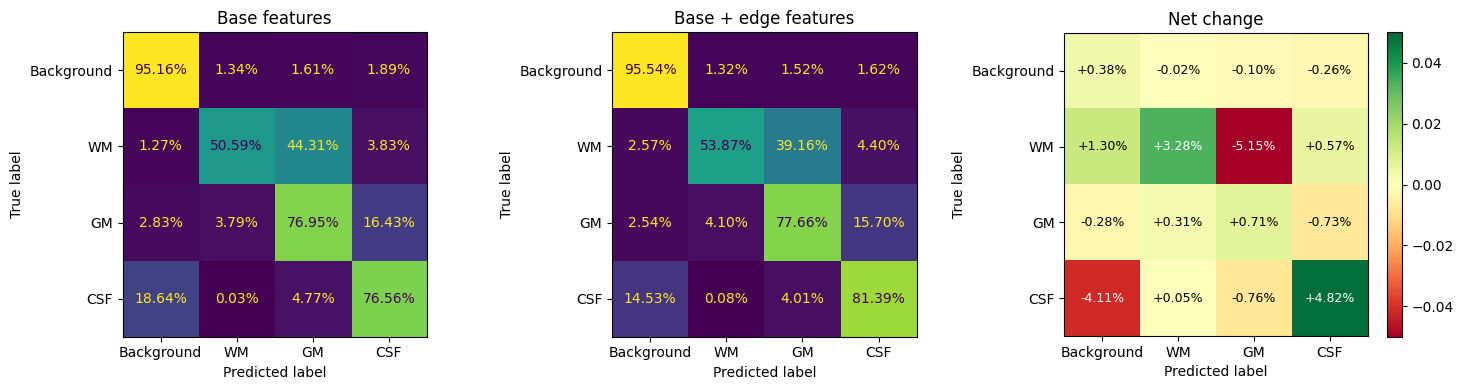

In [47]:
# CONFUSION MATRIX + DIFFERENCES

# set up plots with each tissue type 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['Background', 'WM', 'GM', 'CSF']

# set up confusion matrix + difference plot
base_CM = confusion_matrix(y_test, base_y_pred, normalize='true')
edge_CM = confusion_matrix(y_test, edge_y_pred, normalize='true')
diff_CM = edge_CM - base_CM

# show the normalised matrix for the base features
ConfusionMatrixDisplay(base_CM, display_labels=labels).plot(ax=axes[0], values_format='.2%', colorbar=False)
axes[0].set_title('Base features')

# show the normalised matrix for the base+edge features
ConfusionMatrixDisplay(edge_CM, display_labels=labels).plot(ax=axes[1], values_format='.2%', colorbar=False)
axes[1].set_title('Base + edge features')

# Show the net change (edge - base)
im = axes[2].imshow(diff_CM, cmap='RdYlGn', vmin=-0.05, vmax=0.05)
axes[2].set_xticks(range(len(labels)))
axes[2].set_yticks(range(len(labels)))
axes[2].set_xticklabels(labels)
axes[2].set_yticklabels(labels)
axes[2].set_xlabel('Predicted label')
axes[2].set_ylabel('True label')
axes[2].set_title('Net change')
plt.colorbar(im, ax=axes[2])

# add percentage values to each cell
for i in range(len(labels)):
    for j in range(len(labels)):
        val = diff_CM[i, j]
        # Use black text for small values, white for large to ensure readability
        color = 'black' if abs(val) < 0.03 else 'white'
        axes[2].text(j, i, f'{val:+.2%}', ha='center', va='center', 
                    fontsize=9, color=color)

plt.tight_layout()
plt.savefig('Confusion matrices.png', dpi=500)
plt.show()

To further quantify the effect of adding the edge features, a confusion matrix was made for both feature sets and the net change was also visualised. This reaffirms that background pixels were the most identifiable, and were not really affected by the edge feature. This might be because, as mentioned previously, the bulk of these pixels are not found near tissue boundaries. 

For white matter, there was an increase in correct classification of +3.28% (as seen previously), but this also came with an increase of WM pixels being misclassified as background (+1.30%) and a decrease of WM being misclassified as GM (-5.15%). This suggests that edge features helped diffentiate WM from GM, but at the cost of more WM being categorised as background. 

For grey matter, adding edge features lead to a modest general increase in the correct categorisation. Before edge features were added, misclassification of GM as CSF was the 16.43%. Adding the edge features reduced this by -0.75%, but this is likely a secondary effect of better CSF classification rather than a direct consequence of edge features improving GM segmentation. 

For CSF, there is a significant reduction in misclassified background pixels. This is likely because the initial mask struggled with differentiating between CSF and background at boundaries of the brain, and in the middle section. It can also be seen from the difference map plotted on the true mask that edge features has helped with this. This supports the hypothesis that edge features helped with identifying CSF, especially at the brain-background boundary. There remains a small misclassification of CSF as GM, which suggests that there is still some further differentiation needed on the internal tissue boundaries.

Overall, it can be seen that there is an interplay between the edge detection improving CSF classification by reducing misidentified background pixels and presumably correctly identifying more of these as CSF pixels. By extension, this had a positive effect on grey matter classification which was being misidentified as background or CSF. Additionally, the WM-GM confusion reduction of -5.15% is the largest off-diagonal change in the matrix. This suggests that beyond the effects of CSF, edge features also improved distinguishing between these two. 